In [1]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.odr import ODR, Model, RealData
%run ./HFIR_Experiment_Functions.ipynb
import warnings
warnings.filterwarnings('ignore')

In [2]:
#slow = pd.read_csv('nsrgsc_20240613_2_1.csv', header=None)
slow = pd.read_csv('nsrgsc_20240614_3_1.csv', header=None)

In [8]:
begin=10
#start=1500
#end=len(slow)-5000
end=len(slow)

#start=10
#end=len(slow)

#temp = np.float64(slow[2][begin:end])


# Fluxgate readouts, making the upstream ones negative and dividing x,y,z by 4:
field1 = np.float64(slow[18][begin:end])
field2 = np.float64(slow[19][begin:end])
field3 = np.float64(slow[20][begin:end])
field4 = -np.float64(slow[21][begin:end])
field5 = np.float64(slow[22][begin:end])
fieldx = -np.float64(slow[23][begin:end])/4
fieldy = -np.float64(slow[24][begin:end])/4
fieldz = -np.float64(slow[25][begin:end])/4
error = np.float64(slow[6][begin:end])
index = np.float64(slow[0][begin:end])
time = np.float64(slow[1][begin:end])

# Temperature readouts
TUSBR = np.float64(slow[2][begin:end])
TRADS = np.float64(slow[3][begin:end])
TDSTR = np.float64(slow[4][begin:end])
TDSBL = np.float64(slow[5][begin:end])


# Averaging temps
avg_temp = (TUSBR+TDSTR+TDSBL)/3 

# Put the average where there's no location-specific temp data
temps = [avg_temp,TDSTR,avg_temp,avg_temp,TDSBL,avg_temp,TUSBR,avg_temp] 


# Average top and bottom along gradient
sample_temp = (TUSBR+TDSTR)/2 
fields = np.float64([field1,field2,field3,field4,field5,fieldx,fieldy,fieldz]) #dont use field 5, even tho we have a temp for it

temperrors = []
fielderrors = []
bin_sizes = []

n = 60

#Use field 1 to calculate the steady temp cutoffs, will be the same for all of them
cutoffs = gen_cutoff(time,avg_temp,field1,n) 

for i in np.arange(len(fields)):
    #temperrors.append(np.ones(len(cutoffs))*(np.std(TUSBR)+np.std(TDSTR)+np.std(TDSBL)))
    temperrors.append(np.ones(len(cutoffs))*(0.03)) #from stdevs of avg, but I should propagate all the std's
    fielderrors.append(np.ones(len(cutoffs))*np.std(fields[i]))
    if i==0:
        bin_sizes.append(cutoffs[i])
    else:
        bin_sizes.append(cutoffs[i] - cutoffs[i-1])

temperrors = np.float64(temperrors)
fielderrors = np.float64(fielderrors)
#cutoffs = np.float64(cutoffs)

places=["DSTL", "DSTR", "DSBR", "USTL", "DSBL", "USTR", "USBR", "USBL"]
print(cutoffs)

[120, 3424, 5274, 7507, 9545, 11463, 13562, 15442, 16607]


In [9]:
print(bin_sizes)

[120, 3304, 1850, 2233, 2038, 1918, 2099, 1880]


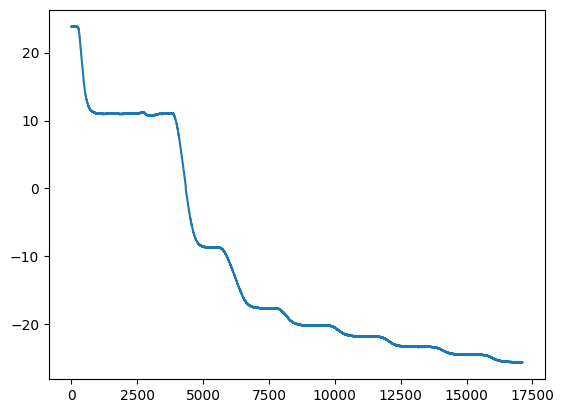

In [10]:
plt.plot(time,avg_temp)

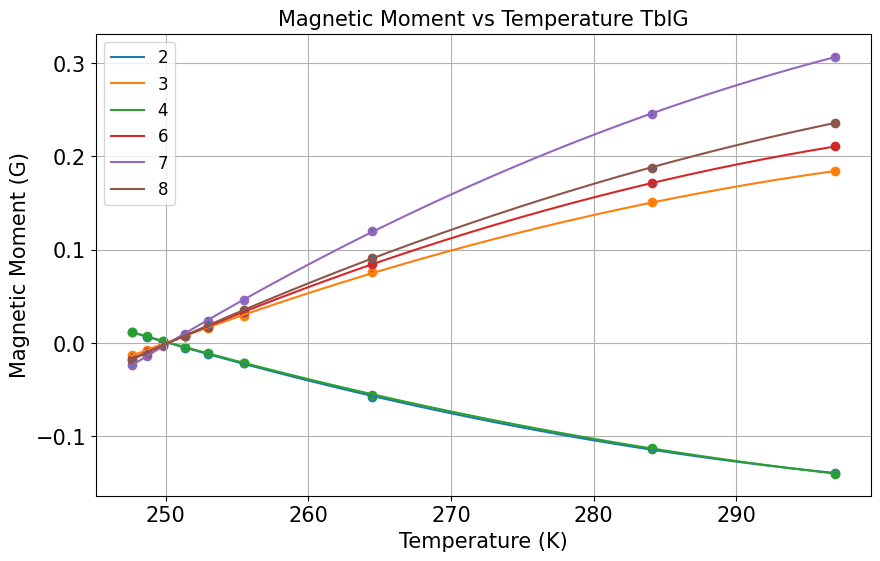

In [30]:
# Define plot space

# Create an inset with a different range in the same figure
# Arguments are: [left, bottom, width, height] in figure coordinates (0 to 1)

#np.ones(9)*tc_back()[i]
#avg[1]-tc_back()[i]

fig,ax = plt.subplots(figsize=(10,6))

#ax_inset = fig.add_axes([0.5, 0.2, 0.1, 0.1])

#labels=["DSTL", "DSTR", "DSBR", "USTL", "DSBL", "USTR", "USBR", "USBL"]
labels=["1", "2", "3", "4", "5", "6", "7", "8"]
#labels=[300, 275, 256, 225, 200]
betas=[]
plots=[]
comps=[]
deltas=[]

j=1

for i in [1,2,3,5,6,7]: #first field gives huge uncertainty sometimes
    temp=sample_temp
    #temp=temps[i]
    avg=np.float64(field_avg(time,fields[i],cutoffs,-22.5,n)[0:2])
    x,y,sigma_x,sigma_y = avg[0]+273.15, avg[1]-total_back()[i], temperrors[i], fielderrors[i]/np.sqrt(bin_sizes[i]) #each bin size is just 2 minutes!
    results=analysis(x, y, sigma_x, sigma_y)
    comps.append(results[2])
    deltas.append(results[3])
    beta=results[0]
    betas.append(beta)
    ax.scatter(x, y)
    ax.errorbar(x, y, xerr=sigma_x, yerr=sigma_y, fmt='none')
    newx=np.arange(min(x), max(x), .1)
    plot=ax.plot(newx,beta[0]*newx**2+beta[1]*newx+beta[2],label=labels[i])
    plots.append(plot)
    #ax_inset.scatter(x, y)
    #ax_inset.errorbar(x, y, xerr=sigma_x, yerr=sigma_y, fmt='none')
    #print(f"Estimated T_comp for {labels[i]}: {np.round(results[2],2)} +/- {np.round(results[3],2)}")

#Total uncertainty is (max-min)/2 divided by sqrt of sample number
#print(f"Total estimated T_comp: {np.round(np.mean(comps),2)} +/- {np.round(np.std(comps),2)}")

SMALL_SIZE = 8
MEDIUM_SIZE = 12
BIGGER_SIZE = 15

plt.rc('font', size=BIGGER_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

# Set plot title and axes labels
ax.set(title = "Magnetic Moment vs Temperature TbIG",
       xlabel = "Temperature (K)",
       ylabel = "Magnetic Moment (G)")

x1, x2, y1, y2 = 299.992, 300.006, 0.07492, 0.07496  # subregion of the original image

# Plot the same data in the inset, but zoomed in
# Zoom in between x=2 and x=3
#ax_inset.set_xlim(x1, x2)
#ax_inset.set_ylim(y1, y2)
#ax_inset.set_xticks([])
#ax_inset.set_yticks([])
#ax_inset.set_title('10k Zoom')

ax.legend(loc = "upper left")

ax.grid()

plt.savefig('HFIR_Tcomp_labels.png',dpi=200)

plt.show(plots)

In [12]:
tc_back()[3]

-0.00856517436398549

In [21]:
back_beta=[]
for i in np.arange(7):
    back_beta.append(betas[i])
    #print(back_beta)

IndexError: list index out of range

for fx 0, tc = [-22.382255938391147]
for fx 1, tc = [-22.288956637060974]
for fx 2, tc = [-22.702938597491645]
for fx 3, tc = [-26.30362269520415]
for fx 4, tc = [-24.114068248262168]
for fx 5, tc = [-23.832382241062433]
for fx 6, tc = [-24.213938306977482]
for total, tc = -23.69116609492143


Text(0.5, 1.0, 'Subtracted Fits')

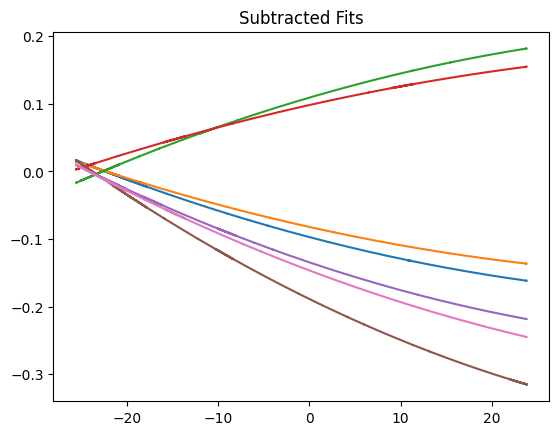

In [95]:
x=avg_temp
beta=[]
xints=0

for i in np.arange(7):
    beta.append(signal_beta[i]-back_beta[i])
    plt.plot(x,beta[i][0]*x**2+beta[i][1]*x+beta[i][2],label=labels[i])
    xint=calculate_x_intercepts(beta[i][0],beta[i][1],beta[i][2])
    print(f"for fx {i}, tc = {xint}")
    xints+=xint[0]
print(f"for total, tc = {xints/7}")
plt.title("Subtracted Fits")

In [293]:
print(x,sigma_x)

[ 23.79689842  10.97872229  -8.68927454 -17.64524636 -20.19498874
 -21.79893384 -23.30764238 -24.45641074 -25.53790324] [0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05]


Estimated T_comp for DSTR: -22.97 +/- 0.25
Estimated T_comp for DSBR: -23.17 +/- 0.35
Estimated T_comp for USTL: -22.88 +/- 0.32
Estimated T_comp for USTR: -22.98 +/- 0.34
Estimated T_comp for USBR: -22.94 +/- 0.34
Estimated T_comp for USBL: -22.96 +/- 0.36
Total estimated T_comp: -22.98 +/- 0.09


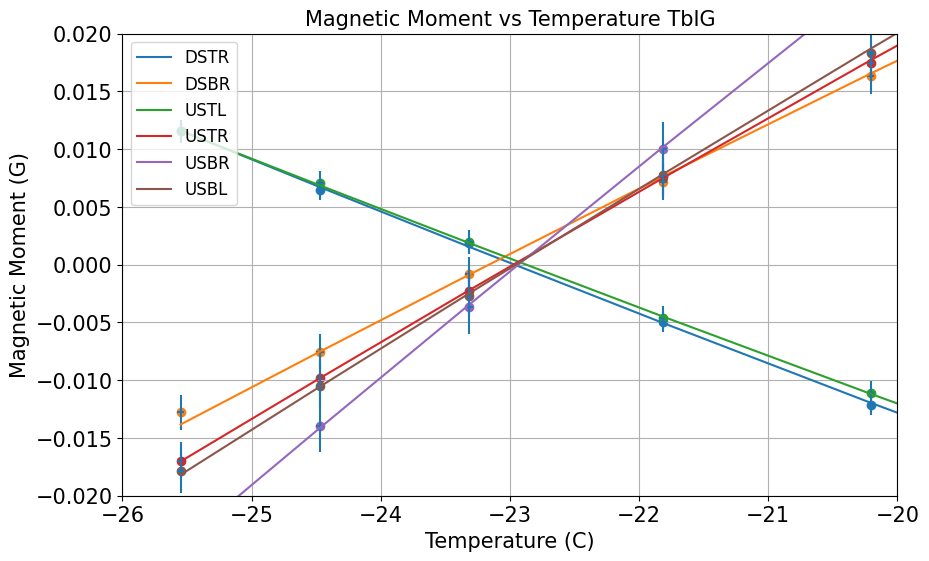

In [22]:
# Define plot space

# Create an inset with a different range in the same figure
# Arguments are: [left, bottom, width, height] in figure coordinates (0 to 1)

#np.ones(9)*tc_back()[i]
#avg[1]-tc_back()[i]

fig,ax = plt.subplots(figsize=(10,6))

#ax_inset = fig.add_axes([0.5, 0.2, 0.1, 0.1])

labels=["DSTL", "DSTR", "DSBR", "USTL", "DSBL", "USTR", "USBR", "USBL"]
#labels=[300, 275, 256, 225, 200]
betas=[]
plots=[]
comps=[]
deltas=[]

j=1

for i in [1,2,3,5,6,7]: #first field gives huge uncertainty sometimes
    temp=sample_temp
    avg=np.float64(field_avg(time,fields[i],cutoffs,-22.5,n)[0:2])
    x,y,sigma_x,sigma_y = avg[0], avg[1]-total_back()[i], temperrors[i], fielderrors[i]/np.sqrt(bin_sizes[i]) #each bin size is just 2 minutes!
    results=analysis(x, y, sigma_x, sigma_y)
    comps.append(results[2])
    deltas.append(results[3])
    beta=results[0]
    betas.append(beta)
    ax.scatter(x, y)
    ax.errorbar(x, y, xerr=sigma_x, yerr=sigma_y, fmt='none')
    plot=ax.plot(x,beta[0]*x**2+beta[1]*x+beta[2],label=labels[i])
    plots.append(plot)
    #ax_inset.scatter(x, y)
    #ax_inset.errorbar(x, y, xerr=sigma_x, yerr=sigma_y, fmt='none')
    print(f"Estimated T_comp for {labels[i]}: {np.round(results[2],2)} +/- {np.round(results[3],2)}")

#Total uncertainty is (max-min)/2 divided by sqrt of sample number
print(f"Total estimated T_comp: {np.round(np.mean(comps),2)} +/- {np.round(np.std(comps),2)}")

# Set plot title and axes labels
ax.set(title = "Magnetic Moment vs Temperature TbIG",
       xlabel = "Temperature (C)",
       ylabel = "Magnetic Moment (G)")

x1, x2, y1, y2 = 299.992, 300.006, 0.07492, 0.07496  # subregion of the original image

# Plot the same data in the inset, but zoomed in
# Zoom in between x=2 and x=3
#ax_inset.set_xlim(x1, x2)
#ax_inset.set_ylim(y1, y2)
#ax_inset.set_xticks([])
#ax_inset.set_yticks([])
#ax_inset.set_title('10k Zoom')

ax.set_xlim(-26, -20)
ax.set_ylim(-.02,0.02)


ax.legend(loc = "upper left")

ax.grid()

plt.savefig('HFIR_Zoomed_Tcomp.png',dpi=100)

plt.show(plots)

#print(betas)



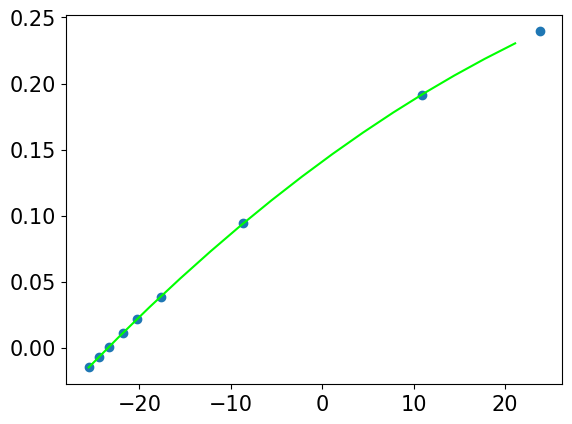

In [24]:
bkg = 0.004187 #background for fluxgate y
field_signal = avg[1]-bkg #subtracting background

z=np.arange(np.min(avg[0]),np.max(avg[0]),30/len(avg[0]))
fit=np.polyfit(avg[0],avg[1],2)
plt.scatter(avg[0],avg[1])
plt.plot(z,fit[0]*z**2+fit[1]*z+fit[2], color="lime")


In [25]:
calculate_x_intercepts(fit[0],fit[1],fit[2])

[-23.452614384376147]

In [26]:
np.min(temps)

-25.730911

In [27]:
np.mean(fields[0][1:1000])

-0.15282374274274277

In [29]:
np.std(fieldy)

0.10667488820161698

In [31]:
sample_temp

array([ 23.7935815,  23.7806505,  23.7418605, ..., -25.5912745,
       -25.5531915, -25.603968 ])